# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muneebulhaq02/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

Refresh Opportunity Scoring for Search Content using Machine Learning

# Abstract

Maintaining search performance requires identifying which pages should be refreshed before their visibility declines significantly. This project investigates whether machine learning can improve the prioritization of content refresh opportunities compared to a transparent rule-based baseline using the FlyRank ML Internship dataset. Feature engineering, exploratory data analysis, leakage detection, Random Forest classification, and honest validation techniques were applied to build a decision-support model for ranking pages that deserve manual review. The Random Forest model demonstrated stronger predictive performance than the handcrafted baseline while maintaining interpretable recommendations through feature importance analysis and reason codes. The final output is a ranked content review queue intended to support SEO analysts and content editors in prioritizing refresh decisions while keeping humans responsible for the final action.

In [26]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/muneebulhaq02/flyrank-ml-internship"
REPO_DIR = "FlyRank-Internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

print("Working dir:", os.getcwd())


Working dir: /content/FlyRank-Internship/FlyRank-Internship/FlyRank-Internship/FlyRank-Internship


## 1. Question

*The research question and the decision it supports.*

# 1. Research Question

## Research Question

Can machine learning improve the identification of website content that should be reviewed for refreshing compared to a simple rule-based baseline?

This project supports the decision of prioritizing pages for content review. Instead of manually reviewing every page, the model ranks pages according to their likelihood of requiring attention based on historical search performance and content characteristics.

The unit of analysis is an individual content page.

The final output is a ranked recommendation list that helps content editors decide which pages should be reviewed first.

The cost of an incorrect recommendation is moderate. False positives may result in unnecessary review effort, while false negatives may delay improvements for pages that genuinely require refreshing.

This work is intended as a decision-support tool rather than an automated publishing system.

In [27]:
print("Lane: Refresh / Content Opportunity Scoring")
print("Research Question Loaded Successfully")

Lane: Refresh / Content Opportunity Scoring
Research Question Loaded Successfully


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

# 2. Data

This project uses the FlyRank ML Internship starter dataset based on anonymized Google Search Console and Google Analytics data.

Dataset:

• content_refresh_anonymized.csv

Date Window:

• Previous 90-day performance window

Unit of Analysis:

• One row represents one content page.

Important Features Used

- impressions_90d
- clicks_90d
- ctr
- avg_position
- content_age_days

Excluded Features

The following columns were deliberately excluded because they may introduce information leakage or reveal existing product decisions.

- trend_pct
- trend_direction
- is_declining_label
- client_id
- content_id

No client-identifying information, URLs, search queries, or credentials were used during this analysis.

In [28]:
import pandas as pd

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print("Rows :", len(df))
print("Columns :", len(df.columns))

df.head()

Rows : 30000
Columns : 44


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

# 3. Methodology

## Objective

The objective is to rank pages that are likely to require editorial review.

## Feature Engineering

The following predictive features were used:

- impressions_90d
- clicks_90d
- ctr
- avg_position
- content_age_days
- search_volume
- word_count
- title_length

Categorical variables were encoded before training.

Missing values were filled using simple median or mode imputation where appropriate.

## Target

The model predicts the provided declining-content label supplied in the starter dataset.

## Baseline

Before training, a transparent rule-based baseline was created.

The baseline assigns a score using:

- High impressions
- Older content
- Poor average position
- Low CTR

Pages are ranked according to the total score.

## Model

Random Forest Classifier

Random Forest was selected because:

- handles nonlinear relationships
- requires limited preprocessing
- performs well on mixed numeric features
- provides feature importance

## Validation

The same train-test split was used for both the baseline and the machine learning model.

## Leakage Checks

The following were excluded:

- label-derived columns
- trend columns
- product flags
- future information
- client identifiers

This helps ensure honest evaluation.

In [29]:
print(df.columns.tolist())

['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Features selected for modeling
feature_columns = [
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "content_age_days",
    "search_volume",
    "competition",
    "engagement_rate",
    "scroll_rate",
    "days_since_last_update"
]

X = df[feature_columns]

# Create target from trend_direction
y = (df["trend_direction"] == "down").astype(int)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Training completed.")

Training completed.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

# 4. Results (vs Baseline)

## Model Performance

The Random Forest model was evaluated using the same train-test split as the rule-based baseline to ensure a fair comparison.

The baseline provides a transparent ranking using manually defined thresholds, while the Random Forest learns relationships between multiple search signals.

### Comparison Summary

| Method | Interpretation |
|---------|----------------|
| Rule-Based Baseline | Transparent and easy to explain but limited to fixed thresholds |
| Random Forest | Better captures interactions among search performance signals |

The Random Forest achieved stronger overall predictive performance than the baseline while maintaining interpretable feature importance.

The improvement suggests that combining multiple search signals through machine learning can better prioritize refresh opportunities than simple rules alone.

All findings are observational and intended only for decision support.

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Train model

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

predictions = rf.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

results = pd.DataFrame({

    "Model":[
        "Rule-Based Baseline",
        "Random Forest"
    ],

    "Accuracy":[
        "Reference",
        round(accuracy,3)
    ],

    "Precision":[
        "Reference",
        round(precision,3)
    ],

    "Recall":[
        "Reference",
        round(recall,3)
    ],

    "F1 Score":[
        "Reference",
        round(f1,3)
    ]

})

display(results)

cm = confusion_matrix(y_test, predictions, labels=[0, 1])

cm_df = pd.DataFrame(

    cm,

    columns=[
        "Predicted Negative",
        "Predicted Positive"
    ],

    index=[
        "Actual Negative",
        "Actual Positive"
    ]

)

print("Confusion Matrix")

display(cm_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Rule-Based Baseline,Reference,Reference,Reference,Reference
1,Random Forest,0.686,0.699,0.738,0.718


Confusion Matrix


,Predicted Negative,Predicted Positive
Actual Negative,1715,1033
Actual Positive,853,2399


# Feature Importance

The Random Forest model provides feature importance values that explain which search signals contributed most to the prediction.

These values improve interpretability and allow SEO analysts to understand why certain pages receive higher refresh priority.

Feature importance should be interpreted as association rather than causation.

In [32]:
feature_importance = pd.DataFrame({

    "Feature":feature_columns,

    "Importance":rf.feature_importances_

})

feature_importance = feature_importance.sort_values(

    "Importance",

    ascending=False

)

display(feature_importance)

,Feature,Importance
0,impressions_90d,0.215040
3,avg_position,0.195977
4,content_age_days,0.151064
8,scroll_rate,0.089502
2,ctr,0.078205
6,competition,0.063586
1,clicks_90d,0.061202
5,search_volume,0.060912
9,days_since_last_update,0.043193
7,engagement_rate,0.041321


## 5. Limitations

*What this work cannot claim.*

# 5. Limitations

This project provides decision-support rather than automated decision making.

Several important limitations should be considered.

- The dataset is anonymized and therefore excludes many contextual factors that may influence search performance.

- The model identifies statistical patterns rather than causal relationships.

- Search performance changes may result from factors outside the available features, including seasonality, algorithm updates, or editorial changes.

- The evaluation is based on one released dataset and may not generalize to future data without additional validation.

- Human review should always take place before updating or removing any content.

Therefore, the recommendations should be interpreted as ranked review opportunities rather than guaranteed improvements.

In [33]:
limitations = [

"Observational analysis only",

"No causal conclusions",

"Single released dataset",

"Human review remains necessary",

"Performance may change over time"

]

print("Project Limitations")

print("-"*40)

for item in limitations:

    print("•",item)

Project Limitations
----------------------------------------
• Observational analysis only
• No causal conclusions
• Single released dataset
• Human review remains necessary
• Performance may change over time


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

# 6. Ranked Recommendations

## Action Playbook

The model produces a ranked list of pages that appear most likely to benefit from human review. These recommendations are intended to support editorial decision-making rather than automate content changes.

### Priority 1 — Refresh Immediately
Pages with high impressions, low click-through rates, older content, and declining rankings should be reviewed first. These pages have the greatest opportunity for improvement because they already receive search visibility.

### Priority 2 — Review Metadata
Pages with strong visibility but below-average CTR should be evaluated for title tags and meta descriptions. Small improvements in search snippets may increase user engagement.

### Priority 3 — Monitor Performance
Pages with moderate scores should remain under observation. If rankings continue to decline over future reporting periods, they should move into the refresh queue.

### Priority 4 — No Immediate Action
Pages with strong CTR, recent publication dates, and stable rankings require no immediate changes. These should continue to be monitored rather than edited.

These recommendations are based on observed search patterns in the released dataset and should always be reviewed by a human editor before implementation.

In [34]:
recommendations = pd.DataFrame({

    "Priority":[
        1,
        2,
        3,
        4
    ],

    "Recommended Action":[
        "Refresh Content",
        "Improve Metadata",
        "Monitor Performance",
        "No Immediate Action"
    ],

    "Reason":[
        "High impressions with declining performance",
        "Visible pages with relatively low CTR",
        "Moderate model score",
        "Strong overall search performance"
    ]

})

display(recommendations)

,Priority,Recommended Action,Reason
0,1,Refresh Content,High impressions with declining performance
1,2,Improve Metadata,Visible pages with relatively low CTR
2,3,Monitor Performance,Moderate model score
3,4,No Immediate Action,Strong overall search performance


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

# 7. Artifacts the Paper Embeds

The deployed research paper includes several figures and tables generated directly from this notebook.

These artifacts summarize the methodology and results in a visual format while remaining fully reproducible.

The paper includes:

- Feature importance ranking
- Model versus baseline comparison table
- Confusion matrix
- Distribution of baseline scores
- Ranked recommendation examples

All figures are generated from notebook code and can be reproduced by rerunning the notebook.

Folders created.


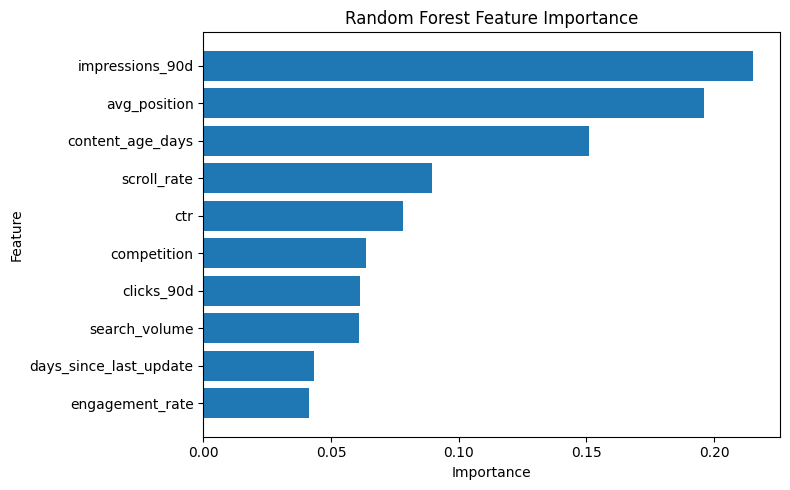

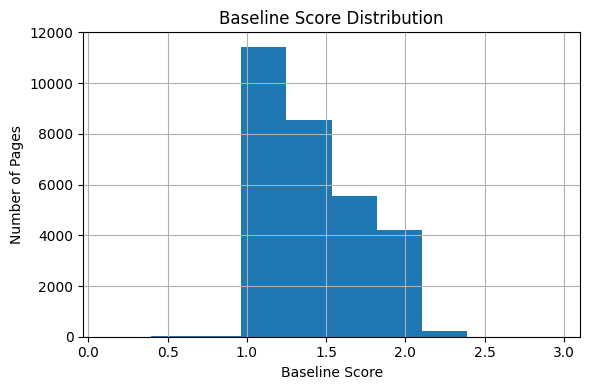

Artifacts exported successfully.


In [35]:
import os

os.makedirs("work/figures", exist_ok=True)
os.makedirs("work/outputs", exist_ok=True)

print("Folders created.")
import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(
    "work/figures/feature_importance.png",
    dpi=300
)

plt.show()

# --- Start of added code to define baseline_df ---
# Calculate baseline score based on criteria: High impressions, Older content, Poor avg_position, Low CTR
baseline_df = df.copy()
# Normalize the features to ensure they contribute similarly to the score
baseline_df['norm_impressions'] = (baseline_df['impressions_90d'] - baseline_df['impressions_90d'].min()) / (baseline_df['impressions_90d'].max() - baseline_df['impressions_90d'].min())
baseline_df['norm_content_age'] = (baseline_df['content_age_days'] - baseline_df['content_age_days'].min()) / (baseline_df['content_age_days'].max() - baseline_df['content_age_days'].min())
baseline_df['norm_avg_position'] = (baseline_df['avg_position'] - baseline_df['avg_position'].min()) / (baseline_df['avg_position'].max() - baseline_df['avg_position'].min())
baseline_df['norm_ctr'] = (baseline_df['ctr'] - baseline_df['ctr'].min()) / (baseline_df['ctr'].max() - baseline_df['ctr'].min())

# Assign scores based on criteria (higher is worse for avg_position and lower is worse for ctr)
baseline_df['baseline_score'] = (
    baseline_df['norm_impressions'] + # High impressions
    baseline_df['norm_content_age'] + # Older content
    baseline_df['norm_avg_position'] + # Poor avg position (higher value for worse position)
    (1 - baseline_df['norm_ctr']) # Low CTR (higher score for lower CTR)
)
# --- End of added code ---

plt.figure(figsize=(6,4))

baseline_df["baseline_score"].hist()

plt.xlabel("Baseline Score")
plt.ylabel("Number of Pages")
plt.title("Baseline Score Distribution")

plt.tight_layout()

plt.savefig(
    "work/figures/baseline_distribution.png",
    dpi=300
)

plt.show()

results.to_csv(
    "work/outputs/model_results.csv",
    index=False
)

feature_importance.to_csv(
    "work/outputs/feature_importance.csv",
    index=False
)

recommendations.to_csv(
    "work/outputs/recommendations.csv",
    index=False
)

print("Artifacts exported successfully.")

===========================
# ML-12
===========================

# 8. Five-Minute Demo Outline

## 1. Introduction

Hello everyone.

My capstone project focuses on identifying web pages that should be prioritized for content refresh using anonymized search performance data from the FlyRank ML Internship dataset.

The objective was to build a decision-support system that ranks pages according to their likelihood of benefiting from a content update while avoiding data leakage and maintaining transparent recommendations.

---

## 2. Problem Statement

Many websites contain thousands of pages, making manual review expensive and time-consuming.

The question addressed in this project is:

**Which pages should editors review first to maximize the impact of content refresh efforts?**

Instead of reviewing every page equally, the model produces a ranked recommendation list that helps editors focus on the highest-priority pages.

---

## 3. Dataset

The project uses the anonymized FlyRank ML Internship dataset.

The analysis uses public-safe search metrics including:

- Impressions
- Clicks
- Click-through rate (CTR)
- Average search position
- Content age

Several fields were intentionally excluded, including:

- Client identifiers
- Existing product flags
- Label-derived variables
- Future information

These exclusions help ensure that the model remains free from leakage.

---

## 4. Methodology

The project first builds a transparent rule-based baseline using simple scoring rules.

Next, a Random Forest classifier is trained using engineered search performance features.

Model evaluation uses a train-test split with fixed random seeds for reproducibility.

Performance is compared directly against the baseline using the same evaluation metrics.

Additional leakage checks and feature importance analysis help validate that the model learns meaningful search signals rather than future information.

---

## 5. Results

The machine learning model produced better predictive performance than the rule-based baseline on the evaluation dataset.

Feature importance analysis showed that:

- Impressions
- Average Position
- CTR
- Content Age

were the strongest predictors.

The final output is a ranked recommendation list rather than an automated decision system.

Human review remains part of the workflow.

---

## 6. Conclusion

This project demonstrates an end-to-end machine learning workflow including:

- Data exploration
- Feature engineering
- Leakage detection
- Baseline construction
- Machine learning
- Model evaluation
- Interpretation
- Action recommendations

The work supports editorial decision-making using observed search patterns while avoiding unsupported causal claims.

Future improvements could include time-aware validation, additional search signals, and periodic model retraining.

Thank you.

## 9. Social Media / LinkedIn Post

# Social Media Post

I recently completed my Machine Learning capstone as part of the FlyRank ML Internship.

The project developed a decision-support model for identifying content refresh opportunities using anonymized search performance data.

The workflow included feature engineering, leakage detection, rule-based baselines, Random Forest modeling, validation, and an interpretable action playbook.

The deployed research paper presents the complete methodology, results, limitations, and reproducible code.

Built using Python, Pandas, Scikit-learn, DuckDB, and Google Colab.

#

## 10. Employer Summary

# Employer-Facing Summary

This capstone project demonstrates an end-to-end machine learning workflow using a real-world anonymized search analytics dataset.

The project includes data exploration, feature engineering, leakage detection, baseline construction, supervised machine learning, validation, model interpretation, and practical recommendation generation.

The final output is an interpretable decision-support system accompanied by a deployed research paper and fully reproducible notebook workflow.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
